<a href="https://colab.research.google.com/github/AlanChi0720/AlanChi0720/blob/main/C_drug_solubility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tour C: Drug Discovery — Molecular Solubility Prediction

**The idea:** A drug molecule can be represented as a SMILES string (e.g., `CC(=O)Oc1ccccc1C(=O)O` is aspirin). RDKit turns SMILES strings into **Morgan fingerprints** — binary vectors that encode which chemical substructures are present, like a molecular barcode.

**What we'll build:** A model that predicts aqueous solubility (logS) from molecular structure alone. This is a core ADMET property — a drug that isn't soluble can't be absorbed.

**Estimated time:** 2–3 hours

In [3]:
!pip install -q rdkit scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 41.2 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem, rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

## 1. Load the Delaney (ESOL) Dataset

1,128 molecules with measured aqueous solubility (logS). A classic ML benchmark in cheminformatics.

In [5]:
import urllib.request

url = 'https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv'
urllib.request.urlretrieve(url, 'delaney.csv')

df = pd.read_csv('delaney.csv')
print(df.shape)
df.head()

(1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


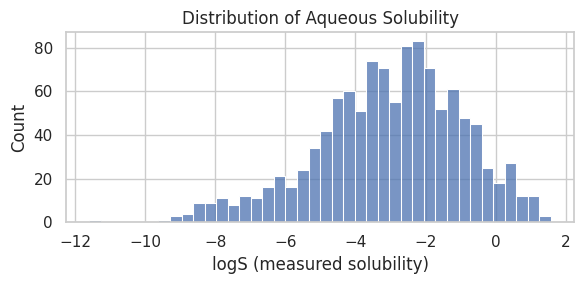

In [6]:
# The target column is 'measured log solubility in mols per litre'
target_col = 'measured log solubility in mols per litre'
smiles_col = 'smiles'

fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(df[target_col], bins=40, ax=ax)
ax.set_xlabel('logS (measured solubility)')
ax.set_title('Distribution of Aqueous Solubility')
plt.tight_layout()
plt.show()

## 2. Convert SMILES to Morgan Fingerprints

Morgan fingerprints (also called circular fingerprints or ECFP) encode the presence of chemical substructures in a fixed-length binary vector. Radius=2, 2048 bits is a standard setting.

In [9]:
def smiles_to_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprintAsNumPy(mol)
    return fp

# Convert all molecules
fps = []
valid_idx = []
for i, smi in enumerate(df[smiles_col]):
    fp = smiles_to_fingerprint(smi)
    if fp is not None:
        fps.append(fp)
        valid_idx.append(i)

X = np.array(fps)
y = df[target_col].values[valid_idx]
print(f'Feature matrix: {X.shape}  (molecules x fingerprint bits)')

Feature matrix: (1128, 2048)  (molecules x fingerprint bits)


## 3. Train and Evaluate

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'Test RMSE: {rmse:.3f} log units')
print(f'Test R²:   {r2:.3f}')

Test RMSE: 1.162 log units
Test R²:   0.714


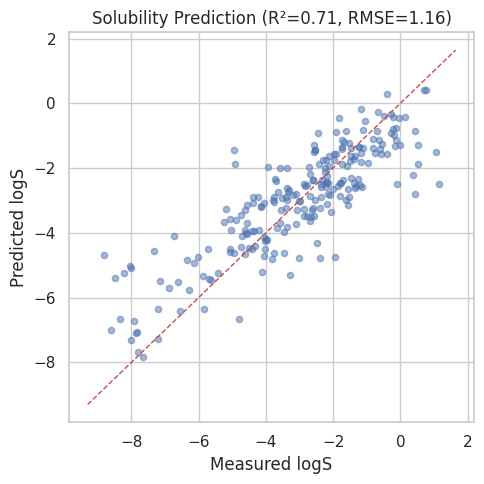

In [11]:
# Predicted vs. actual plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, alpha=0.5, s=20)
lim = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_xlabel('Measured logS')
ax.set_ylabel('Predicted logS')
ax.set_title(f'Solubility Prediction (R²={r2:.2f}, RMSE={rmse:.2f})')
plt.tight_layout()
plt.show()

## 4. Visualize Some Molecules

Look at the most and least soluble molecules. Does the chemistry make sense?

Most Soluble Molecules


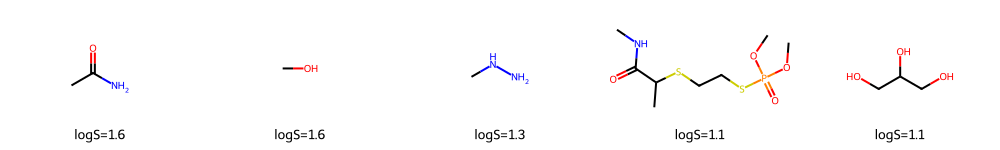

In [12]:
df_valid = df.iloc[valid_idx].copy()
df_valid['logS'] = y

# Top 5 most soluble and 5 least soluble
most_soluble = df_valid.nlargest(5, 'logS')
least_soluble = df_valid.nsmallest(5, 'logS')

def draw_mols(smiles_list, labels, title):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 150),
                               legends=[f'logS={l:.1f}' for l in labels])
    print(title)
    return img

draw_mols(most_soluble[smiles_col], most_soluble['logS'], 'Most Soluble Molecules')

Least Soluble Molecules


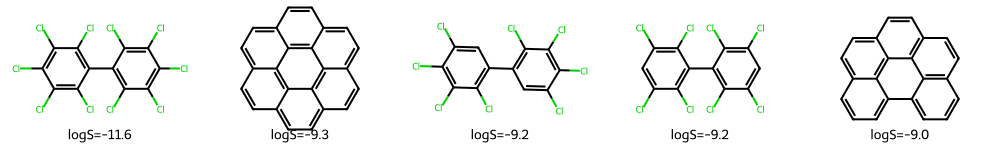

In [13]:
draw_mols(least_soluble[smiles_col], least_soluble['logS'], 'Least Soluble Molecules')

# Q: Do the least soluble ones look more hydrophobic / aromatic?
# Do the most soluble ones have more polar groups (OH, NH2, COOH)?

## 5. Compute Drug-Likeness Descriptors (Lipinski)

Lipinski's Rule of Five says a drug-like molecule should have: MW < 500, logP < 5, H-bond donors ≤ 5, H-bond acceptors ≤ 10.

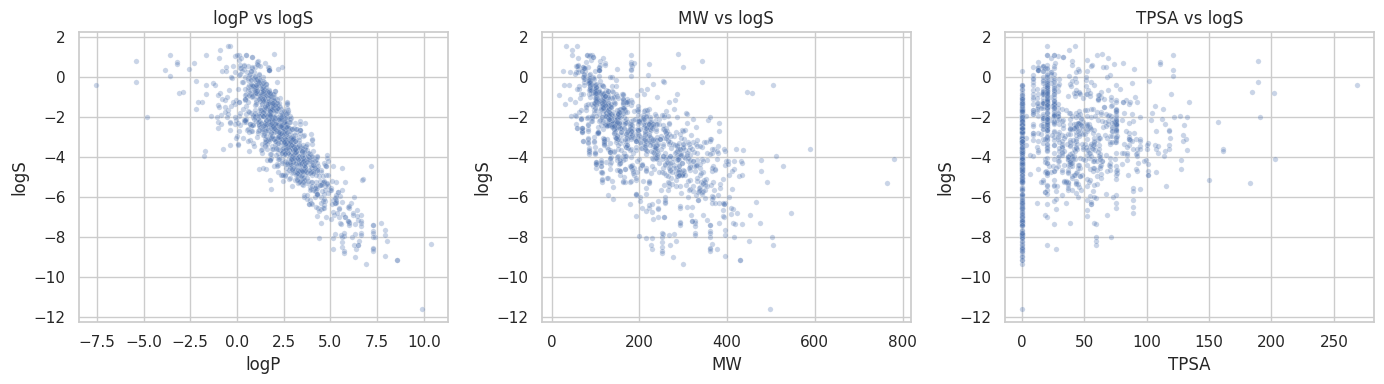

In [14]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MW': Descriptors.MolWt(mol),
        'logP': Descriptors.MolLogP(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
    }

desc_list = [compute_descriptors(s) for s in df_valid[smiles_col]]
desc_df = pd.DataFrame(desc_list)
desc_df['logS'] = y

# Correlate descriptors with solubility
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['logP', 'MW', 'TPSA']):
    sns.scatterplot(data=desc_df, x=col, y='logS', alpha=0.3, s=15, ax=ax)
    ax.set_title(f'{col} vs logS')
plt.tight_layout()
plt.show()

# Q: logP (lipophilicity) should strongly correlate with (in)solubility. Does it?

<Axes: xlabel='TPSA', ylabel='logS'>

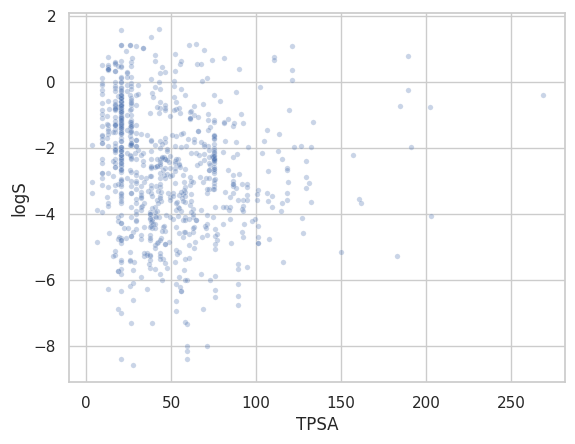

In [15]:
desc_nonzero = desc_df[desc_df['TPSA'] > 0]
sns.scatterplot(data=desc_nonzero, x='TPSA', y='logS', alpha=0.3, s=15)

## Reflection Questions

1. RMSE is in log units — a 1 unit error means the model's prediction is 10x off. Is that acceptable for a drug screening tool?
2. The fingerprint representation ignores 3D conformation. How might that limit the model?
3. What other ADMET properties would you want to predict besides solubility?
4. Does drug discovery / cheminformatics interest you enough to continue to Phase 3 Track C?

# Phase 2 Track C — Drug Solubility Prediction 複習筆記

## 核心概念

### SMILES
分子的文字表示法，例如阿斯匹靈：`CC(=O)Oc1ccccc1C(=O)O`。
RDKit 把 SMILES 解析成分子物件，再計算各種性質。

---

### Morgan Fingerprint（ECFP）
**分子的「結構條碼」**——把分子轉成 ML 能吃的數字向量。

- 從每個原子出發，往外擴展 `radius` 個鍵的範圍
- 每個「原子 + 周圍環境」的子結構 hash 成一個數字
- 對應到一個 2048 位的 0/1 向量

```python
# 舊 API（會有 deprecation warning）
AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

# 新 API（推薦）
from rdkit.Chem import rdFingerprintGenerator
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = gen.GetFingerprintAsNumPy(mol)
```

> 類比：和 DNA k-mer 的概念一樣，都是把「序列/結構」轉成固定長度向量。

---

### Delaney (ESOL) 資料集
- 1128 個分子，目標值為實測水溶解度 `logS`（單位：log mol/L）
- 欄位包含：SMILES、measured logS、MW、logP、HBD、HBA、Polar Surface Area 等

---

## 模型訓練流程

```
SMILES → Morgan Fingerprint → X (1128 × 2048)
                                    ↓
                         train_test_split (80/20)
                                    ↓
                      RandomForestRegressor.fit(X_train, y_train)
                                    ↓
                         predict(X_test) → 評估 RMSE, R²
```

---

## 評估指標

| 指標 | 意思 | 解讀 |
|------|------|------|
| **RMSE** | 預測偏離幾個 log 單位 | RMSE = 1 → 平均預測錯 10 倍；越小越好 |
| **R²** | 模型解釋了多少溶解度變異 | 越接近 1 越好；> 0.8 算不錯 |

> 在藥物早期篩選中，RMSE ~1 log unit 通常勉強可接受（快速過濾用），但不能取代實驗數據。

---

## Lipinski's Rule of Five

口服藥物通常符合：

| 性質 | 條件 |
|------|------|
| 分子量 MW | < 500 Da |
| 脂溶性 logP | < 5 |
| 氫鍵供體 HBD | ≤ 5 |
| 氫鍵受體 HBA | ≤ 10 |

---

## 描述符 vs logS 的相關性（實驗結果）

| 描述符 | 與 logS 的關係 | 生物原因 |
|--------|---------------|----------|
| **logP** | 強負相關 ✓ | 越親油越不溶於水 |
| **MW** | 負相關 ✓ | 分子越大通常越難溶 |
| **TPSA** | 正相關（但圖形被 TPSA=0 的分子壓縮） | 極性基團多 → 可與水形成氫鍵 → 溶解度高 |

> TPSA 圖有垂直條紋是因為大量疏水分子（純烴、多環芳烴）TPSA = 0，濾掉後趨勢才明顯。

---

## 模型的限制

1. **忽略 3D 構型**：Morgan fingerprint 只編碼 2D 拓撲結構，兩個構型不同但 SMILES 相似的分子會得到接近的指紋，但實際性質可能不同。

2. **訓練集偏差**：Delaney 資料集偏向小分子藥物，對大型生物分子（抗體、多肽）預測力差。

3. **外推能力有限**：Random Forest 不擅長預測訓練集分布以外的分子。

---

## 延伸：其他 ADMET 性質

溶解度（S）只是 ADMET 的一環：

- **A**bsorption — 吸收（與溶解度直接相關）
- **D**istribution — 分布（logP、血腦屏障穿透性）
- **M**etabolism — 代謝（CYP450 酶的受質預測）
- **E**xcretion — 排泄（腎清除率）
- **T**oxicity — 毒性（hERG 通道抑制、肝毒性）